In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

# TAMBAHKAN INI
df = df.sample(100000, random_state=42)

In [4]:
df.info()
df.describe()
df['type'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 369582 to 523030
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  object 
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  object 
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  object 
 7   oldbalanceDest  99999 non-null   float64
 8   newbalanceDest  99999 non-null   float64
 9   isFraud         99999 non-null   float64
 10  isFlaggedFraud  99999 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 9.2+ MB


,count
type,
CASH_OUT,35659
PAYMENT,33990
CASH_IN,21441
TRANSFER,8176
DEBIT,734


In [5]:
df = df[df['type'].isin(['CASH_OUT', 'TRANSFER', 'PAYMENT'])]

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Class'] = le.fit_transform(df['type'])

df[['type', 'Class']].head()

,type,Class
287315,TRANSFER,2
123969,CASH_OUT,0
257978,PAYMENT,1
310626,PAYMENT,1
508124,PAYMENT,1


In [7]:
df = df.drop(['nameOrig', 'nameDest', 'type'], axis=1)

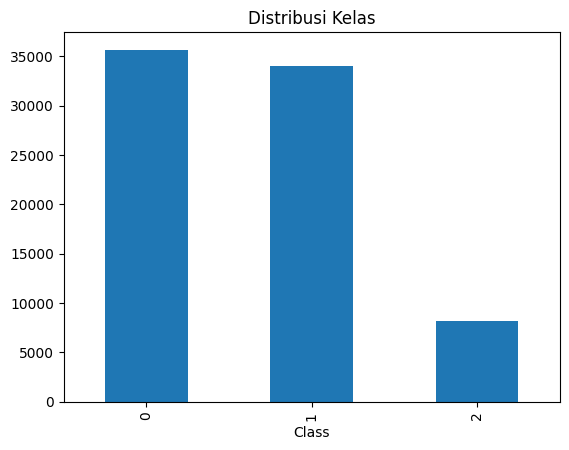

In [8]:
df['Class'].value_counts().plot(kind='bar')
plt.title("Distribusi Kelas")
plt.show()

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

In [10]:
# Cek jumlah NaN
print(df.isna().sum())

step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
Class             0
dtype: int64


In [11]:
df = df.fillna(0)

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

results = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    svm = SVC()
    lr = LogisticRegression(max_iter=1000)

    # RF
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    # SVM
    svm.fit(X_train_scaled, y_train)
    y_pred_svm = svm.predict(X_test_scaled)

    # LR
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)

    for model_name, y_pred in zip(
        ["Random Forest", "SVM", "Logistic Regression"],
        [y_pred_rf, y_pred_svm, y_pred_lr]
    ):
        results.append({
            "Split": split_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='weighted'),
            "Recall": recall_score(y_test, y_pred, average='weighted'),
            "F1": f1_score(y_test, y_pred, average='weighted')
        })

df_results = pd.DataFrame(results)
df_results

,Split,Model,Accuracy,Precision,Recall,F1
0,70:30,Random Forest,0.934812,0.932741,0.934812,0.927173
1,70:30,SVM,0.910913,0.912135,0.910913,0.900229
2,70:30,Logistic Regression,0.914682,0.913367,0.914682,0.905348
3,80:20,Random Forest,0.934019,0.931422,0.934019,0.926403
4,80:20,SVM,0.911340,0.912501,0.911340,0.900118
5,80:20,Logistic Regression,0.915194,0.913592,0.915194,0.905574
6,90:10,Random Forest,0.932031,0.928829,0.932031,0.924118
7,90:10,SVM,0.914043,0.915104,0.914043,0.903132
8,90:10,Logistic Regression,0.916742,0.915362,0.916742,0.907166


In [14]:
from imblearn.over_sampling import SMOTE

results_smote = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # 🔥 TAMBAHAN SMOTE (INI YANG PENTING)
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_smote)
    X_test_scaled = scaler.transform(X_test)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    svm = SVC()
    lr = LogisticRegression(max_iter=1000)

    # RF
    rf.fit(X_train_smote, y_train_smote)
    y_pred_rf = rf.predict(X_test)

    # SVM
    svm.fit(X_train_scaled, y_train_smote)
    y_pred_svm = svm.predict(X_test_scaled)

    # LR
    lr.fit(X_train_scaled, y_train_smote)
    y_pred_lr = lr.predict(X_test_scaled)

    for model_name, y_pred in zip(
        ["Random Forest", "SVM", "Logistic Regression"],
        [y_pred_rf, y_pred_svm, y_pred_lr]
    ):
        results_smote.append({
            "Split": split_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='weighted'),
            "Recall": recall_score(y_test, y_pred, average='weighted'),
            "F1": f1_score(y_test, y_pred, average='weighted')
        })

df_results_smote = pd.DataFrame(results_smote)
df_results_smote

,Split,Model,Accuracy,Precision,Recall,F1
0,70:30,Random Forest,0.909585,0.910080,0.909585,0.909827
1,70:30,SVM,0.897379,0.893266,0.897379,0.894562
2,70:30,Logistic Regression,0.872494,0.884522,0.872494,0.875789
3,80:20,Random Forest,0.911532,0.911407,0.911532,0.911469
4,80:20,SVM,0.899647,0.895274,0.899647,0.896755
5,80:20,Logistic Regression,0.876454,0.886925,0.876454,0.879479
6,90:10,Random Forest,0.911345,0.910528,0.911345,0.910926
7,90:10,SVM,0.902994,0.898078,0.902994,0.899707
8,90:10,Logistic Regression,0.878325,0.887788,0.878325,0.881171


In [15]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [17]:
from sklearn.model_selection import GridSearchCV

results_rf = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    param_grid = {
        'n_estimators': [200],
        'max_depth': [10, None]
    }

    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=3,
        n_jobs=-1
    )

    grid.fit(X_train_smote, y_train_smote)
    y_pred = grid.best_estimator_.predict(X_test)

    results_rf.append({
        "Split": split_name,
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted')
    })

df_rf = pd.DataFrame(results_rf)
df_rf

,Split,Model,Accuracy,Precision,Recall,F1
0,70:30,Random Forest,0.908686,0.909724,0.908686,0.909185
1,80:20,Random Forest,0.911340,0.911610,0.911340,0.911473
2,90:10,Random Forest,0.912373,0.911168,0.912373,0.911745


In [19]:
results_svm = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_smote)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {
        'C': [1, 10],
        'kernel': ['rbf']
    }

    grid = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1)
    grid.fit(X_train_scaled, y_train_smote)

    y_pred = grid.best_estimator_.predict(X_test_scaled)

    results_svm.append({
        "Split": split_name,
        "Model": "SVM",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted')
    })

df_svm = pd.DataFrame(results_svm)
df_svm

,Split,Model,Accuracy,Precision,Recall,F1
0,70:30,SVM,0.908943,0.905053,0.908943,0.906634
1,80:20,SVM,0.909155,0.905190,0.909155,0.906823
2,90:10,SVM,0.913786,0.908941,0.913786,0.910727


In [20]:
results_lr = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_smote)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {
        'C': [0.1, 1, 10]
    }

    grid = GridSearchCV(
        LogisticRegression(max_iter=1000),
        param_grid,
        cv=3,
        n_jobs=-1
    )

    grid.fit(X_train_scaled, y_train_smote)

    y_pred = grid.best_estimator_.predict(X_test_scaled)

    results_lr.append({
        "Split": split_name,
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted')
    })

df_lr = pd.DataFrame(results_lr)
df_lr

,Split,Model,Accuracy,Precision,Recall,F1
0,70:30,Logistic Regression,0.881446,0.893552,0.881446,0.885470
1,80:20,Logistic Regression,0.883970,0.894689,0.883970,0.887596
2,90:10,Logistic Regression,0.885134,0.894827,0.885134,0.888479


In [21]:
df_final = pd.concat([df_rf, df_svm, df_lr])
df_final

,Split,Model,Accuracy,Precision,Recall,F1
0,70:30,Random Forest,0.908686,0.909724,0.908686,0.909185
1,80:20,Random Forest,0.911340,0.911610,0.911340,0.911473
2,90:10,Random Forest,0.912373,0.911168,0.912373,0.911745
0,70:30,SVM,0.908943,0.905053,0.908943,0.906634
1,80:20,SVM,0.909155,0.905190,0.909155,0.906823
2,90:10,SVM,0.913786,0.908941,0.913786,0.910727
0,70:30,Logistic Regression,0.881446,0.893552,0.881446,0.885470
1,80:20,Logistic Regression,0.883970,0.894689,0.883970,0.887596
2,90:10,Logistic Regression,0.885134,0.894827,0.885134,0.888479


In [23]:
# PREDIKSI (WAJIB PAKAI X_test)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Re-run GridSearchCV for Random Forest on the 80:20 split to get 'best_rf'
# The X_train, X_test, y_train, y_test are already set from a 80:20 split in cell 80qSsWmFRZV2
param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [10, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train_smote, y_train_smote)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

# EVALUASI

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      3566
           1       1.00      1.00      1.00      3399
           2       0.59      0.57      0.58       818

    accuracy                           0.91      7783
   macro avg       0.83      0.83      0.83      7783
weighted avg       0.91      0.91      0.91      7783



In [24]:
svm = SVC()
svm.fit(X_train_scaled, y_train_smote)

y_pred_svm = svm.predict(X_test_scaled)

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))

=== SVM ===
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      3566
           1       0.95      1.00      0.97      3399
           2       0.68      0.57      0.62       818

    accuracy                           0.90      7783
   macro avg       0.84      0.82      0.83      7783
weighted avg       0.90      0.90      0.90      7783



In [25]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.82      0.86      3566
           1       0.96      1.00      0.98      3399
           2       0.50      0.63      0.56       818

    accuracy                           0.88      7783
   macro avg       0.79      0.82      0.80      7783
weighted avg       0.89      0.88      0.88      7783



In [26]:
from sklearn.metrics import classification_report

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      3566
           1       1.00      1.00      1.00      3399
           2       0.59      0.57      0.58       818

    accuracy                           0.91      7783
   macro avg       0.83      0.83      0.83      7783
weighted avg       0.91      0.91      0.91      7783

=== SVM ===
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      3566
           1       0.95      1.00      0.97      3399
           2       0.68      0.57      0.62       818

    accuracy                           0.90      7783
   macro avg       0.84      0.82      0.83      7783
weighted avg       0.90      0.90      0.90      7783

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.82      0.86      3566
           1       0.96      1.00      0.98      3399
           2 

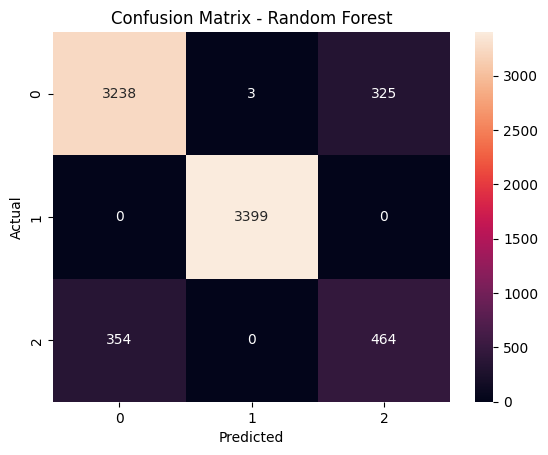

In [27]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

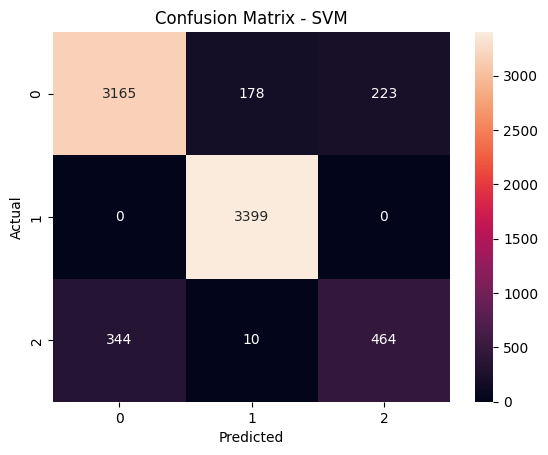

In [28]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

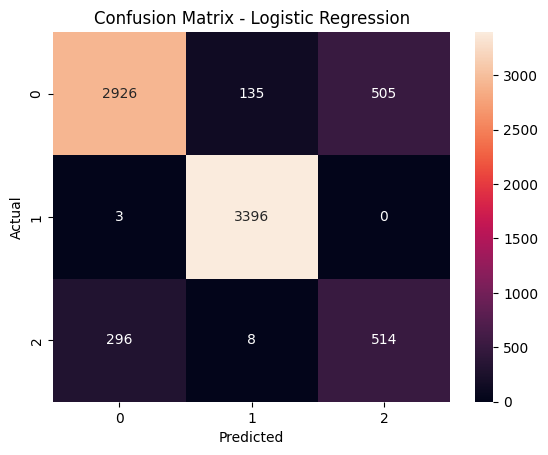

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for model_name, y_pred in zip(
    ["Random Forest", "SVM", "Logistic Regression"],
    [y_pred_rf, y_pred_svm, y_pred_lr]  # 🔥 hasil SETELAH tuning
):
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted')
    })

df_compare = pd.DataFrame(results)
df_compare

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.912373,0.911168,0.912373,0.911745
1,SVM,0.902994,0.898078,0.902994,0.899707
2,Logistic Regression,0.878325,0.887788,0.878325,0.881171


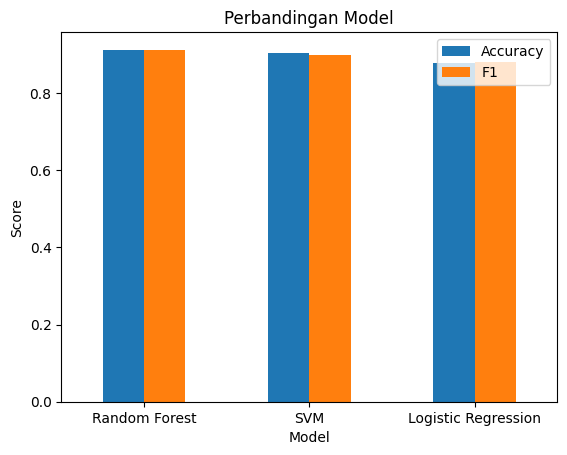

In [31]:
df_compare.set_index("Model")[["Accuracy", "F1"]].plot(kind='bar')

plt.title("Perbandingan Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [32]:
best_model = df_compare.loc[df_compare['Accuracy'].idxmax()]
best_model

,0
Model,Random Forest
Accuracy,0.912373
Precision,0.911168
Recall,0.912373
F1,0.911745


In [33]:
import pandas as pd

# 🔥 contoh data baru
data_baru = [[
    200,
    2,          # Class (TRANSFER)
    800000,     # amount
    1000000,
    200000,
    0,
    800000,
    0
]]

# ubah ke dataframe
data_baru_df = pd.DataFrame(data_baru, columns=X.columns)

# 🔥 prediksi model (jenis transaksi)
prediksi = best_rf.predict(data_baru_df)

label_map = {
    0: "CASH_OUT",
    1: "PAYMENT",
    2: "TRANSFER"
}

jenis = label_map[prediksi[0]]

# 🔥 ambil nilai amount
amount = data_baru_df["amount"].values[0]

# =========================
# 🔥 RULE-BASED FRAUD LOGIC
# =========================
if jenis in ["TRANSFER", "CASH_OUT"] and amount > 500000:
    status = "FRAUD"
elif jenis in ["TRANSFER", "CASH_OUT"]:
    status = "BERPOTENSI FRAUD"
else:
    status = "BUKAN FRAUD"

# =========================
# OUTPUT
# =========================
print("Jenis Transaksi:", jenis)
print("Jumlah:", amount)
print("Status Fraud (berdasarkan rule):", status)

Jenis Transaksi: CASH_OUT
Jumlah: 2
Status Fraud (berdasarkan rule): BERPOTENSI FRAUD


In [34]:
import joblib

joblib.dump(best_rf, "model.pkl")

['model.pkl']